In [59]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential, load_model

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [60]:
df = pd.read_csv("../datasets/parkinsons_real/parkinsons_telemonitoring_updrs.csv")

display(df.head())

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [61]:
df = df.sort_values(
    ["subject#","test_time"]
).reset_index(drop=True)

display(df.head())

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.160060
1,1,72,0,5.6431,28.199,34.398,0.00348,0.000015,0.00124,0.00133,...,0.113,0.00411,0.00463,0.00949,0.01234,0.009238,27.927,0.37340,0.52499,0.170660
2,1,72,0,5.6438,28.199,34.398,0.00413,0.000021,0.00173,0.00165,...,0.125,0.00555,0.00651,0.01103,0.01665,0.030790,26.641,0.50911,0.53637,0.251830
3,1,72,0,5.6451,28.199,34.398,0.00217,0.000011,0.00086,0.00099,...,0.072,0.00271,0.00354,0.00781,0.00812,0.004547,30.749,0.41216,0.54572,0.094704
4,1,72,0,5.6458,28.199,34.399,0.00294,0.000015,0.00121,0.00125,...,0.098,0.00459,0.00495,0.00888,0.01377,0.014919,27.530,0.40986,0.53572,0.166350


In [62]:
feature_columns = [

    "age",

    "sex",

    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",

    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",

    "NHR",
    "HNR",

    "RPDE",

    "DFA",

    "PPE",

    "motor_UPDRS"

]

In [63]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    df[feature_columns]
)

scaled_df = pd.DataFrame(
    scaled,
    columns=feature_columns
)

joblib.dump(
    scaler,
    "../models/parkinsons_lstm_scaler.joblib"
)

['../models/parkinsons_lstm_scaler.joblib']

In [64]:
SEQUENCE_LENGTH = 10
X = []
y = []

patient_ids = []

feature_count = len(feature_columns)

for patient in df["subject#"].unique():

    patient_df = scaled_df[
        df["subject#"] == patient
    ].reset_index(drop=True)

    values = patient_df.values

    for i in range(
        len(values) - SEQUENCE_LENGTH
    ):

        sequence = values[
            i:i+SEQUENCE_LENGTH
        ]

        target = values[
            i+SEQUENCE_LENGTH,
            feature_columns.index("motor_UPDRS")
        ]

        X.append(sequence)

        y.append(target)

        patient_ids.append(patient)

In [65]:
X = np.array(X)

y = np.array(y)

print(X.shape)

print(y.shape)

(5455, 10, 19)
(5455,)


In [66]:
print(X[0].shape)

print(y[0])

(10, 19)
0.6790559650512135


In [67]:
from sklearn.model_selection import GroupShuffleSplit

groups = np.array(patient_ids)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("Training Patients :", len(np.unique(groups[train_idx])))
print("Testing Patients  :", len(np.unique(groups[test_idx])))

print()

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Patients : 33
Testing Patients  : 9

Training Samples : 4310
Testing Samples  : 1145


In [68]:
model = Sequential()

model.add(

    LSTM(

        64,

        input_shape=(

            X_train.shape[1],

            X_train.shape[2]

        ),

        return_sequences=True

    )

)

model.add(

    Dropout(0.2)

)

model.add(

    LSTM(

        32

    )

)

model.add(

    Dropout(0.2)

)

model.add(

    Dense(

        16,

        activation="relu"

    )

)

model.add(

    Dense(

        1

    )
)

In [69]:
model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,465 (134.63 KB)

 Trainable params: 34,465 (134.63 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    "../models/parkinsons_lstm.keras",

    save_best_only=True

)

In [71]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[

        early_stop,

        checkpoint

    ],

    verbose=1

)

Epoch 1/100


108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0211 - mae: 0.0974 - val_loss: 0.0014 - val_mae: 0.0306
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038 - mae: 0.0451 - val_loss: 0.0015 - val_mae: 0.0324
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0029 - mae: 0.0399 - val_loss: 0.0026 - val_mae: 0.0452
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - mae: 0.0355 - val_loss: 0.0013 - val_mae: 0.0319
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0019 - mae: 0.0317 - val_loss: 0.0014 - val_mae: 0.0296
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016 - mae: 0.0294 - val_loss: 9.6809e-04 - val_mae: 0.0259
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0015 - mae: 0.0284 - val_loss: 0.0010 - val_mae: 0.0253
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0013 - mae: 0.0268 - val_loss: 0.0020 - val_mae: 0.0359
Epoch 9/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - l

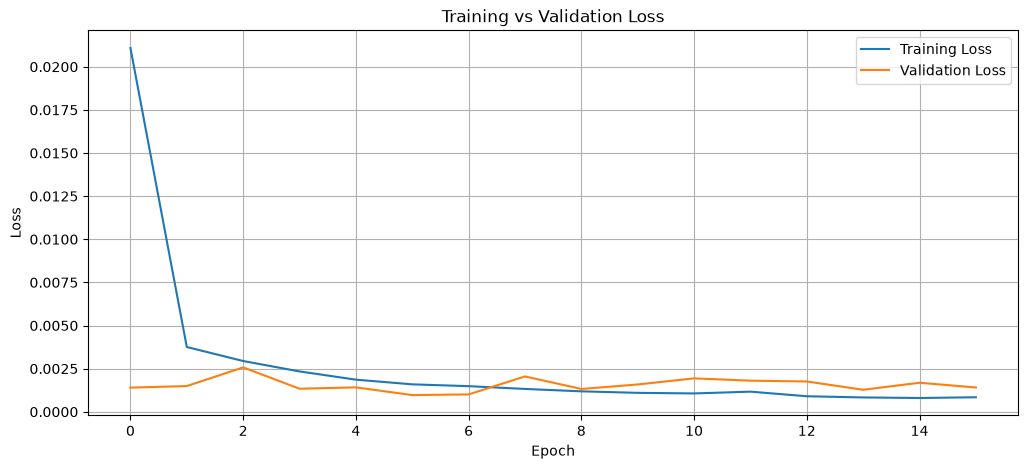

In [72]:
# ==========================================================
# Training History
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [73]:
# ==========================================================
# Predictions
# ==========================================================
train_pred = model.predict(X_train).flatten()

test_pred = model.predict(X_test).flatten()

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [74]:
# -----------------------------
# TRAIN
# -----------------------------

train_mae = mean_absolute_error(
    y_train,
    train_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_pred
    )
)

train_r2 = r2_score(
    y_train,
    train_pred
)

# -----------------------------
# TEST
# -----------------------------

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

test_r2 = r2_score(
    y_test,
    test_pred
)
print("="*60)
print("TRAIN METRICS")
print("="*60)

print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print()

print("="*60)
print("TEST METRICS")
print("="*60)

print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

TRAIN METRICS
MAE  : 0.0161
RMSE : 0.0214
R²   : 0.9920

TEST METRICS
MAE  : 0.0150
RMSE : 0.0187
R²   : 0.9925


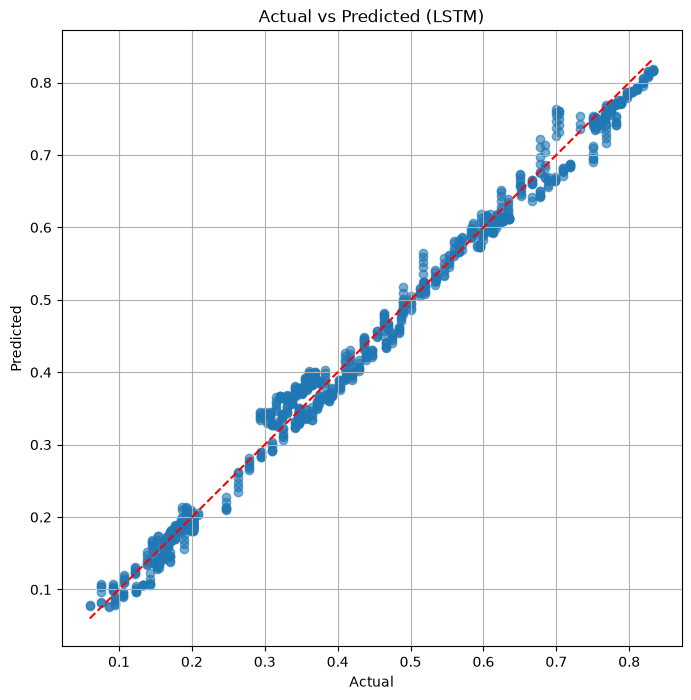

In [75]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted (LSTM)")

plt.grid(True)

plt.show()

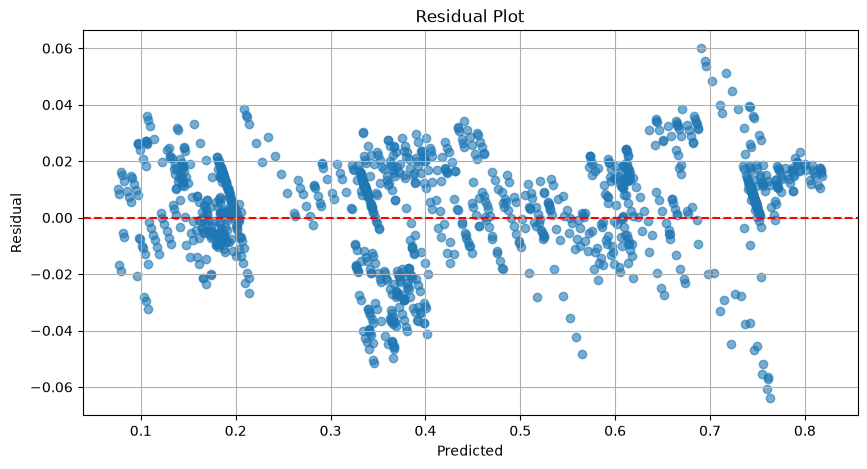

In [76]:
residuals = y_test - test_pred

plt.figure(figsize=(10,5))

plt.scatter(
    test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [77]:
metrics = {

    "Test_MAE": float(test_mae),

    "Test_RMSE": float(test_rmse),

    "Test_R2": float(test_r2)

}

import json

with open(
    "../models/parkinsons_lstm_metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

print(metrics)

{'Test_MAE': 0.01502648442033044, 'Test_RMSE': 0.018748388012039745, 'Test_R2': 0.992548722078844}


In [78]:
model.save(
    "../models/parkinsons_lstm.keras"
)

print("LSTM Saved Successfully")

LSTM Saved Successfully


In [79]:
loaded_model = load_model(
    "../models/parkinsons_lstm.keras"
)

In [80]:
prediction = loaded_model.predict(
    X_test[:1]
)

print("Prediction :", prediction[0][0])
print("Actual     :", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
Prediction : 0.744916
Actual     : 0.7531132789724221


In [81]:
joblib.dump(
    scaler,
    "../models/parkinsons_lstm_scaler.joblib"
)
joblib.dump(
    feature_columns,
    "../models/parkinsons_lstm_features.joblib"
)

['../models/parkinsons_lstm_features.joblib']

In [82]:
print("="*60)
print("PARKINSON'S LSTM TRAINING COMPLETED")
print("="*60)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

print()

print(f"Sequence Length : {SEQUENCE_LENGTH}")

print(f"Features        : {len(feature_columns)}")

print()

print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

print()

print("Saved Files")

print("- parkinsons_lstm.keras")

print("- parkinsons_lstm_scaler.joblib")

print("- parkinsons_lstm_features.joblib")

print("- parkinsons_lstm_metrics.json")

PARKINSON'S LSTM TRAINING COMPLETED
Training Samples : 4310
Testing Samples  : 1145

Sequence Length : 10
Features        : 19

MAE  : 0.0150
RMSE : 0.0187
R²   : 0.9925

Saved Files
- parkinsons_lstm.keras
- parkinsons_lstm_scaler.joblib
- parkinsons_lstm_features.joblib
- parkinsons_lstm_metrics.json
